<a href="https://colab.research.google.com/github/starsyntaxx/End-to-End-Machine-Learning-Project/blob/main/notebook/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Problem Statement:**

The Nigerian used-car market contains a large number of vehicle listings with substantial variation in price based on factors such as vehicle make and model, age, mileage, transmission type, fuel type, engine characteristics, condition, and location.

However, determining whether a listed price is reasonable can be difficult for buyers and sellers because the relationship between these vehicle characteristics and market price is not always straightforward. Similar vehicles can be listed at significantly different prices, while inexperienced buyers may have limited information with which to assess the value of a vehicle.

This project aims to develop a supervised machine learning regression model that predicts the market price of a used car from its observable characteristics.

In [ ]:
from google.colab import drive
import pandas as pd

In [ ]:
# 1. Mount Google Drive
drive.mount('/content/dripve')

Mounted at /content/drive


In [ ]:
# 2. Path to your dataset in Google Drive
zip_path = "/content/drive/MyDrive/ML PROJECTS/nigeria-car-price-prediction/data/raw/nigeria_car_data.zip"

In [ ]:
#unzip file
import zipfile

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(
        "/content/drive/MyDrive/ML PROJECTS/nigeria-car-price-prediction/data/raw/"
    )

In [ ]:
# 3. Load the dataset
car_df = pd.read_csv(zip_path)

# 4. Inspect it
print("Shape:", car_df.shape)
car_df.head(10)

Shape: (1217, 19)


,Unnamed: 0,Make,Model,Year of Manufacture,Color,Price,Location,Trim,Drivetrain,Engine Size,Number of Cylinders,Horse Power,Interior Color,Seats,Registered Car,Second Condition,Body,Exchange Possible,VIN Chassis number
0,0,Mercedes-Benz,C180,2000,Blue,4000000.0,Kano,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Mercedes-Benz,E350,2014,Black,13500000.0,Abuja,Base 4Matic Sedan AWD (3.5L 6cyl 7A),All Wheel,3500cc,6.0,302hp,Brown,5,Yes,NaN,NaN,NaN,NaN
2,2,Toyota,Sienna,2012,Black,16999999.0,Lagos,SE 8 Passenger,Front Wheel,3500cc,6.0,270hp,Black,8,No,No faults,Minivan,No,NaN
3,3,Mercedes-Benz,GLE-Class,2021,Blue,190000000.0,Lagos,AMG GLE 53 4MATIC,All Wheel,3000cc,6.0,429hp,Other,5,No,No faults,SUV,NaN,NaN
4,4,Honda,Accord,2005,Silver,2800000.0,Kaduna,2.4 Type S Automatic,Front Wheel,NaN,NaN,NaN,Black,NaN,Yes,"First owner, First registration, No faults",NaN,NaN,NaN
5,5,Mercedes-Benz,GLC-Class,2019,Gray,62500000.0,Lagos,NaN,NaN,NaN,NaN,NaN,Black,NaN,Yes,No faults,NaN,NaN,NaN
6,6,Lexus,GS,2007,Blue,7500000.0,Lagos,350 4WD,All Wheel,3500cc,6.0,307hp,Other,5,Yes,"No faults, First registration",Sedan,Yes,NaN
7,7,Lexus,ES,2009,Silver,10500000.0,Lagos,350,Front,NaN,6.0,NaN,Black,5,Yes,"First registration, First owner",Sedan,No,NaN
8,8,Acura,TLX,2016,Black,17500000.0,Abuja,Tech V6 SH-AWD (3.5L 6cyl 9A),All Wheel,3500cc,6.0,NaN,Other,NaN,No,No faults,NaN,Yes,NaN
9,9,Lexus,RX,2017,Off white,38700000.0,Lagos,350 FWD,Front Wheel,3500cc,6.0,295hp,Gray,5,Yes,"First owner, Original parts, No faults",SUV,NaN,NaN


In [ ]:
df.describe()

,Unnamed: 0,Year of Manufacture,Price,Number of Cylinders
count,1217.000000,1217.000000,1.217000e+03,763.000000
mean,608.000000,2013.914544,3.287482e+07,5.941022
std,351.461947,4.054026,3.521778e+07,1.119117
min,0.000000,1971.000000,2.600000e+06,3.000000
25%,304.000000,2012.000000,1.655000e+07,6.000000
50%,608.000000,2014.000000,2.630000e+07,6.000000
75%,912.000000,2016.000000,3.900000e+07,6.000000
max,1216.000000,2024.000000,5.120000e+08,12.000000


In [ ]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1217 entries, 0 to 1216
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           1217 non-null   int64  
 1   Make                 1217 non-null   object 
 2   Model                1217 non-null   object 
 3   Year of Manufacture  1217 non-null   int64  
 4   Color                1217 non-null   object 
 5   Price                1217 non-null   float64
 6   Location             1217 non-null   object 
 7   Trim                 824 non-null    object 
 8   Drivetrain           704 non-null    object 
 9   Engine Size          705 non-null    object 
 10  Number of Cylinders  763 non-null    float64
 11  Horse Power          659 non-null    object 
 12  Interior Color       1020 non-null   object 
 13  Seats                695 non-null    object 
 14  Registered Car       1000 non-null   object 
 15  Second Condition     1027 non-null   o

In [ ]:
car_df['Make'].unique()

array(['Mercedes-Benz', 'Toyota', 'Honda', 'Lexus', 'Acura', 'Nissan',
       'Kia', 'Land Rover', 'Ford', 'BMW', 'Rover', 'Peugeot',
       'International', 'Hyundai', 'Geely', 'Hozon', 'Mitsubishi',
       'Volkswagen', 'Pontiac', 'Buick', 'Infiniti', 'Porsche', 'Jaguar'],
      dtype=object)

Split Dataset: Train, Validation, and Test
Stratified sampling will be used to make the splits representative of an important distribution in the dataset.

Question: What distribution do I want my train, validation, and test sets to preserve?

Initially, Make was considered because it is an important categorical feature in predicting car prices. However, the distribution of Make is highly imbalanced, with some manufacturers having only a handful of observations. Stratifying on such a variable could result in unreliable representation of rare categories across the three splits.

Since the target variable, Price, is also highly skewed, the dataset will instead be stratified by price ranges (bins). This ensures that the train, validation, and test sets contain a similar proportion of lower-, middle-, and higher-priced vehicles.

Decision: Stratify by Price bins rather than Make.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit


def create_stratified_splits(
    df,
    output_dir="data/processed",
    test_size=0.1,
    validation_size=0.1,
    n_price_bins=5,
    random_state=42
):
    """
    Create train, validation, and test sets using stratified sampling
    based on binned car prices.

    The resulting datasets are saved as CSV files.
    """

    df = df.copy()

    # ---------------------------------------------------------
    # 1. Create price bins for stratification
    # ---------------------------------------------------------
    df["price_cat"] = pd.qcut(
        df["Price"],
        q=n_price_bins,
        labels=False,
        duplicates="drop"
    )

    # ---------------------------------------------------------
    # 2. First split: separate the test set
    # ---------------------------------------------------------
    test_split = StratifiedShuffleSplit(
        n_splits=1,
        test_size=test_size,
        random_state=random_state
    )

    train_val_idx, test_idx = next(
        test_split.split(df, df["price_cat"])
    )

    train_val = df.iloc[train_val_idx]
    test = df.iloc[test_idx]

    # ---------------------------------------------------------
    # 3. Second split: separate validation from training
    # ---------------------------------------------------------
    # Validation should represent 10% of the ORIGINAL dataset.
    # Since train_val is 90%, validation needs to be 10/90.
    validation_ratio = validation_size / (1 - test_size)

    val_split = StratifiedShuffleSplit(
        n_splits=1,
        test_size=validation_ratio,
        random_state=random_state
    )

    train_idx, val_idx = next(
        val_split.split(train_val, train_val["price_cat"])
    )

    train = train_val.iloc[train_idx]
    validation = train_val.iloc[val_idx]

    # ---------------------------------------------------------
    # 4. Remove temporary price category
    # ---------------------------------------------------------
    train = train.drop(columns="price_cat")
    validation = validation.drop(columns="price_cat")
    test = test.drop(columns="price_cat")

    # ---------------------------------------------------------
    # 5. Create output directory
    # ---------------------------------------------------------
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # ---------------------------------------------------------
    # 6. Save datasets
    # ---------------------------------------------------------
    train.to_csv(output_dir / "train.csv", index=False)
    validation.to_csv(output_dir / "validation.csv", index=False)
    test.to_csv(output_dir / "test.csv", index=False)

    print("Datasets created and saved.")
    print(f"Train:      {train.shape}")
    print(f"Validation: {validation.shape}")
    print(f"Test:       {test.shape}")

    return train, validation, test

In [ ]:

from pathlib import Path
import pandas as pd

processed_dir = Path("data/processed")

train_path = processed_dir / "train.csv"
validation_path = processed_dir / "validation.csv"
test_path = processed_dir / "test.csv"


if train_path.exists() and validation_path.exists() and test_path.exists():

    print("Existing datasets found. Loading them...")

    train_set = pd.read_csv(train_path)
    validation_set = pd.read_csv(validation_path)
    test_set = pd.read_csv(test_path)

else:

    print("Saved datasets not found. Creating stratified splits...")

    train_set, validation_set, test_set = create_stratified_splits(
        car_df,
        output_dir=processed_dir
    )

Saved datasets not found. Creating stratified splits...
Datasets created and saved.
Train:      (973, 19)
Validation: (122, 19)
Test:       (122, 19)


**More Explanatory analysis on Train set**

In [ ]:
import matplotlib.pyplot as plt

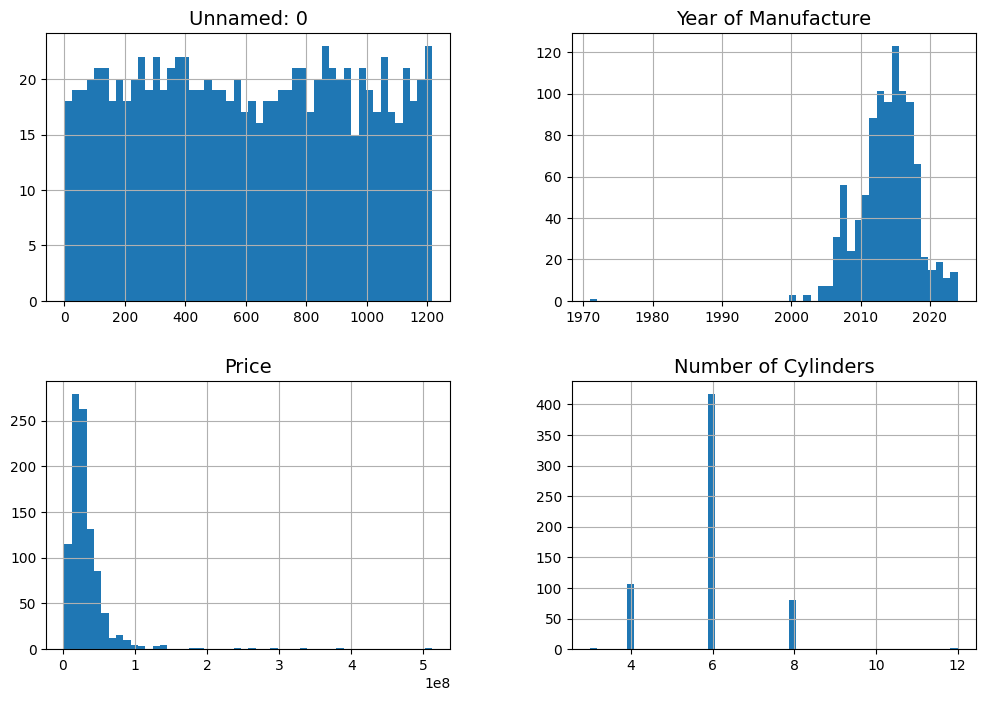

In [ ]:
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

train_set.hist(bins=50, figsize=(12, 8))
plt.show()

In [ ]:

categorical_cols = [
    "Make",
    "Color",
    "Location",
    "Trim",
    "Drivetrain",
    "Interior Color",
    "Registered Car",
    "Second Condition",
    "Body",
    "Exchange Possible"
]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(train_set[col].value_counts().head(15))


--- Make ---
Make
Lexus            325
Mercedes-Benz    310
Toyota           262
Hyundai           21
Land Rover        14
Honda             10
Ford               5
Nissan             4
Acura              3
Rover              2
Volkswagen         2
BMW                2
Kia                2
Peugeot            2
Infiniti           1
Name: count, dtype: int64

--- Color ---
Color
Black         288
White         175
Gray          129
Silver        117
Blue           71
Red            71
Gold           44
Brown          31
Burgundy       13
Green          12
Other           8
Matt Black      5
Beige           4
Off white       3
Yellow          1
Name: count, dtype: int64

--- Location ---
Location
Lagos      857
Abuja       84
Kano        10
Enugu        8
Ondo         3
Oyo          3
Kaduna       2
Anambra      2
Rivers       1
Delta        1
Ogun         1
Kwara        1
Name: count, dtype: int64

--- Trim ---
Trim
350                                                      67
350 4MATIC 